In [ ]:
!pip install tensorflow numpy matplotlib pillow

In [ ]:
!pip install opendatasets
import opendatasets as od
od.download("https://www.kaggle.com/datasets/olafkrastovski/handwritten-digits-0-9")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: riyaindap
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/olafkrastovski/handwritten-digits-0-9


100%|██████████| 66.7M/66.7M [00:00<00:00, 1.30GB/s]

In [ ]:
import os
import numpy as np
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Set the directory where your dataset is stored
dataset_dir = '/content/handwritten-digits-0-9'

# Define image dimensions (we're resizing to 28x28 like MNIST)
img_height, img_width = 28, 28

# Initialize lists to store the images and labels
images = []
labels = []

# Loop through each directory (digit)
for label in range(10):
    folder_path = os.path.join(dataset_dir, str(label))

    # Loop through each image in the folder
    for filename in os.listdir(folder_path):
        image_path = os.path.join(folder_path, filename)

        # Load the image, resize it to 28x28, and convert to a numpy array
        img = load_img(image_path, target_size=(img_height, img_width), color_mode="grayscale")
        img_array = img_to_array(img)

        # Normalize the image
        img_array = img_array / 255.0

        # Append the image and label
        images.append(img_array)
        labels.append(label)

# Convert lists to numpy arrays
images = np.array(images)
labels = np.array(labels)

# Print the shape of the data
print(f"Images shape: {images.shape}, Labels shape: {labels.shape}")


Images shape: (21555, 28, 28, 1), Labels shape: (21555,)


In [ ]:
# Split the data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42)

# Check the shape of the resulting datasets
print(f"Training data shape: {x_train.shape}, Test data shape: {x_test.shape}")


Training data shape: (17244, 28, 28, 1), Test data shape: (4311, 28, 28, 1)


In [ ]:
# Convert labels to one-hot encoding
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)


In [ ]:
from tensorflow.keras import layers, models

# Define the CNN model
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')  # 10 output classes (digits 0-9)
])

# Print the model summary
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 1, 1, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,474 (431.54 KB)

 Trainable params: 110,474 (431.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])


In [ ]:
history = model.fit(x_train, y_train, epochs=5, batch_size=32, validation_data=(x_test, y_test))


Epoch 1/5
539/539 ━━━━━━━━━━━━━━━━━━━━ 23s 39ms/step - accuracy: 0.3865 - loss: 1.7068 - val_accuracy: 0.8223 - val_loss: 0.5370
Epoch 2/5
539/539 ━━━━━━━━━━━━━━━━━━━━ 18s 33ms/step - accuracy: 0.8617 - loss: 0.4437 - val_accuracy: 0.8912 - val_loss: 0.3313
Epoch 3/5
539/539 ━━━━━━━━━━━━━━━━━━━━ 19s 35ms/step - accuracy: 0.9099 - loss: 0.2786 - val_accuracy: 0.9139 - val_loss: 0.2731
Epoch 4/5
539/539 ━━━━━━━━━━━━━━━━━━━━ 18s 33ms/step - accuracy: 0.9361 - loss: 0.1955 - val_accuracy: 0.9267 - val_loss: 0.2274
Epoch 5/5
539/539 ━━━━━━━━━━━━━━━━━━━━ 18s 33ms/step - accuracy: 0.9483 - loss: 0.1655 - val_accuracy: 0.9269 - val_loss: 0.2253


In [ ]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test accuracy: {test_acc}")


135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9314 - loss: 0.2255
Test accuracy: 0.9269310832023621


135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


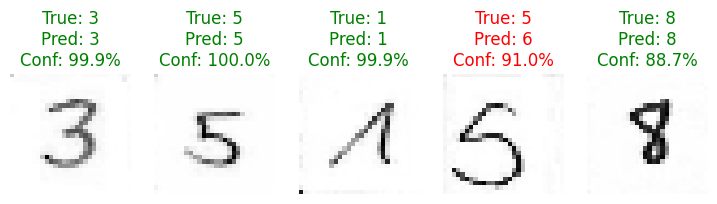

In [ ]:
# Predict probabilities for test images
predictions = model.predict(x_test)

# Convert one-hot encoded true labels back to class integers
true_labels = np.argmax(y_test, axis=1)

# Convert prediction probabilities to class integers
predicted_labels = np.argmax(predictions, axis=1)

# Function to plot images with predictions and confidence scores
def plot_images(images, true_labels, predicted_labels, predictions, num_images=5):
    plt.figure(figsize=(9, 3))
    for i in range(num_images):
        plt.subplot(1, num_images, i + 1)
        plt.imshow(images[i].reshape(28, 28), cmap='gray')
        plt.axis('off')

        true_label = true_labels[i]
        pred_label = predicted_labels[i]
        confidence = np.max(predictions[i]) * 100

        color = 'green' if true_label == pred_label else 'red'
        plt.title(f"True: {true_label}\nPred: {pred_label}\nConf: {confidence:.1f}%", color=color)
    plt.show()

# Plot first 5 test images with their predictions
plot_images(x_test, true_labels, predicted_labels, predictions, num_images=5)